First, we import packages.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

Then, we provide the data from .csv to pandas dataframes (remember to first download the files into data/raw folder and unzip it there).

In [2]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
df = pd.read_csv(RAW_DATA_DIR / "train.csv")
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nInfo:")
df.info()
print("\nDescribe (numeric):")
print(df.describe())
print("\nDescribe (categorical/bool):")
print(df.describe(include=["object", "bool"]))

Shape: (8693, 14)

Dtypes:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   f

In [4]:
missing_per_col = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_per_col / len(df) * 100).round(2)
missing_per_row = df.isna().sum(axis=1)
overall_missing = df.isna().sum().sum()
overall_cells = df.size
overall_missing_pct = (overall_missing / overall_cells * 100).round(2)
print("\nMissing values per column:")
print(pd.DataFrame({"missing": missing_per_col, "pct": missing_pct}))
print("\nAverage missing values per row:", missing_per_row.mean().round(2))
print("Median missing values per row:", missing_per_row.median())
print("Rows with any missing:", (missing_per_row > 0).mean().round(3))
print("Overall missing cells:", overall_missing)
print("Overall missing %:", overall_missing_pct)


Missing values per column:
              missing   pct
CryoSleep         217  2.50
ShoppingMall      208  2.39
VIP               203  2.34
HomePlanet        201  2.31
Name              200  2.30
Cabin             199  2.29
VRDeck            188  2.16
Spa               183  2.11
FoodCourt         183  2.11
Destination       182  2.09
RoomService       181  2.08
Age               179  2.06
PassengerId         0  0.00
Transported         0  0.00

Average missing values per row: 0.27
Median missing values per row: 0.0
Rows with any missing: 0.24
Overall missing cells: 2324
Overall missing %: 1.91


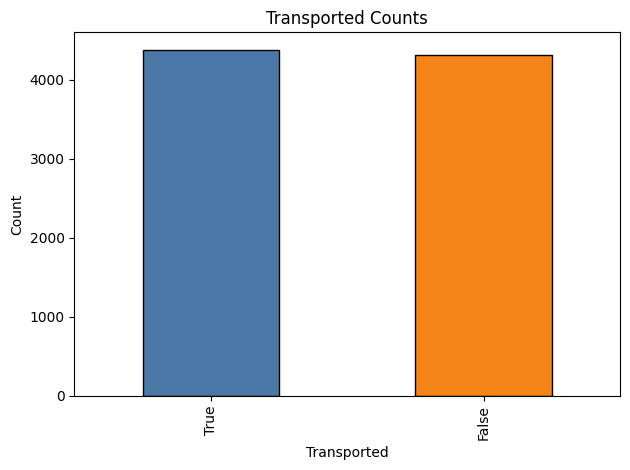

In [ ]:
transported_counts = df["Transported"].value_counts(dropna=False)
ax = transported_counts.plot(
    kind="bar", color=["#4C78A8", "#F58518"], edgecolor="black"
)
ax.set_title("Transported Counts")
ax.set_xlabel("Transported")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Dataset is balanced (at least in a training set), so no need to do any weightning.

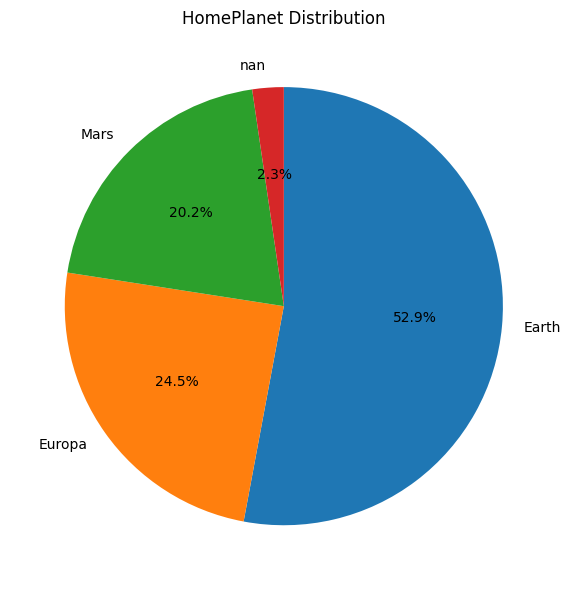

In [6]:
homeplanet_counts = df["HomePlanet"].value_counts(dropna=False)
plt.figure(figsize=(6, 6))
homeplanet_counts.plot.pie(autopct="%1.1f%%", startangle=90, counterclock=False)
plt.title("HomePlanet Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

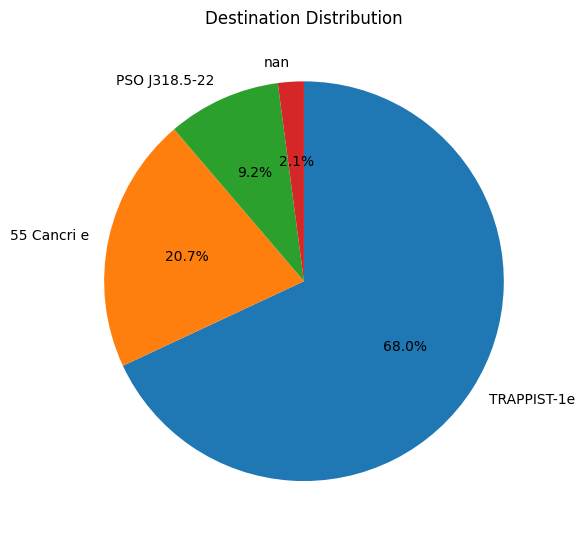

In [7]:
destination_counts = df["Destination"].value_counts(dropna=False)
plt.figure(figsize=(6, 6))
destination_counts.plot.pie(autopct="%1.1f%%", startangle=90, counterclock=False)
plt.title("Destination Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

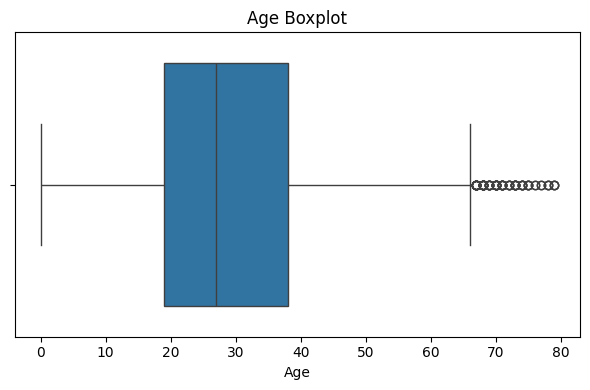

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

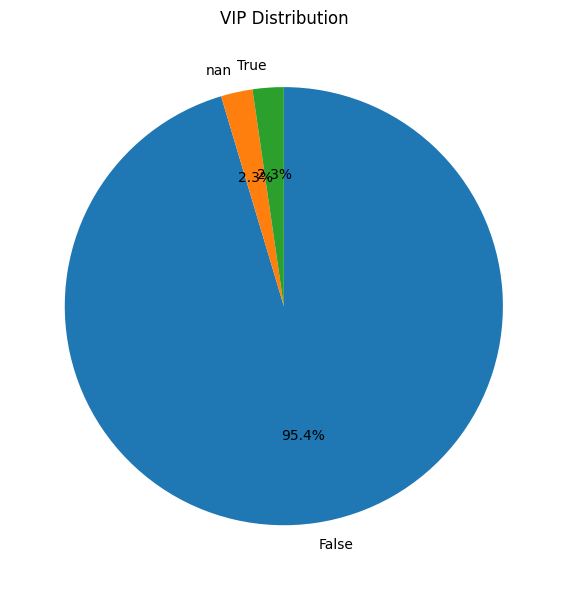

In [9]:
vip_counts = df["VIP"].value_counts(dropna=False)
plt.figure(figsize=(6, 6))
vip_counts.plot.pie(autopct="%1.1f%%", startangle=90, counterclock=False)
plt.title("VIP Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

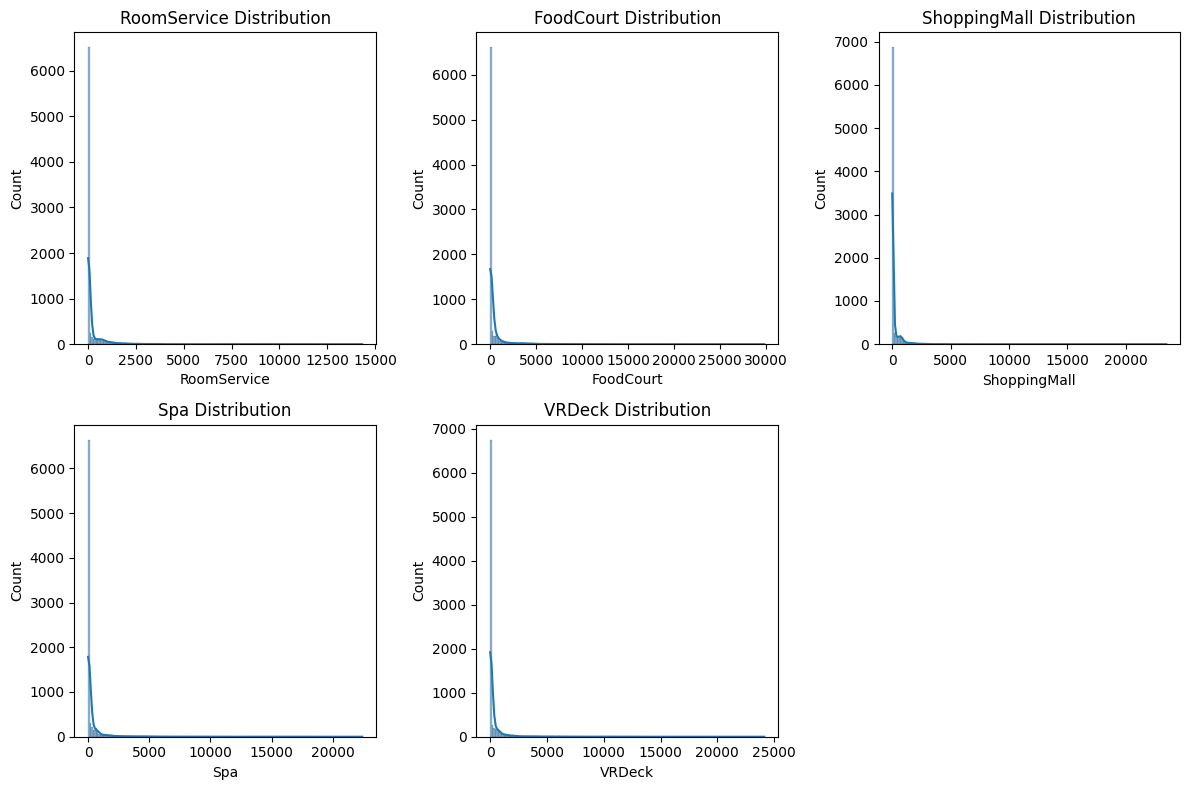

In [10]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(spend_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

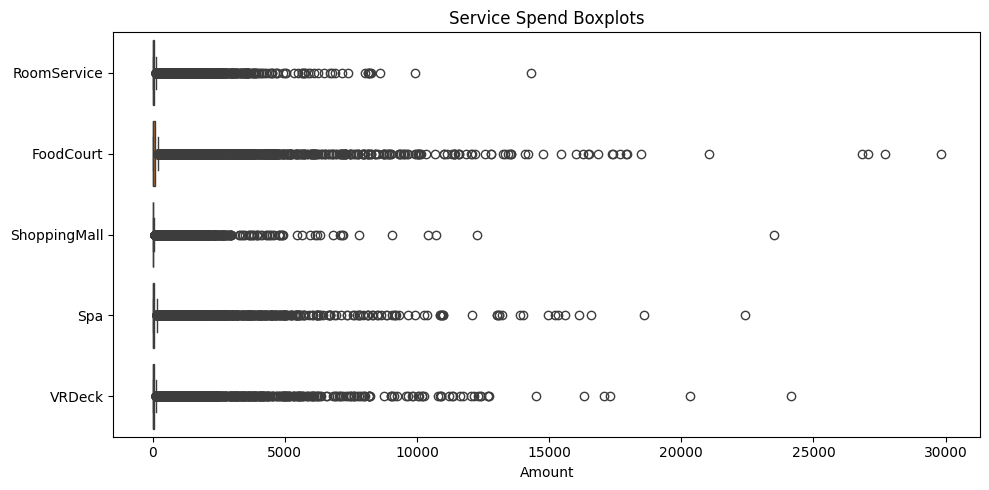

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[spend_cols], orient="h")
plt.title("Service Spend Boxplots")
plt.xlabel("Amount")
plt.tight_layout()
plt.show()